# Slice direction

The bifiltration is collapsed to a 1-D filtration by slicing along a
line `y = s * x + b`. The default `(s, b) = (1, 0)` gives the `y = x`
slice. 


How does clustering ARI change as the slope `s` or
   the offset `b` varies?


How does the resulting dendrogram evolve along the
   same sweep?

In [1]:
from pathlib import Path

import numpy as np                                                                                                                                                                                                  
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram                                                                                                                                                                      
from sklearn.datasets import load_breast_cancer, load_iris                                                                                                                                                          
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score                                                                                                                                                                     
from sklearn.preprocessing import StandardScaler                                                                                                                                                                    

from mpc.bifiltration_processor import BifiltrationProcessor                                                                                                                                                        
from mpc.clustering_utils import ClusteringUtils
from mpc.filtration_builder import FiltrationBuilder                                                                                                                                                                
from mpc.pipeline import normalize_filtration
                                                                                                                                                                                                                    
FIG = Path("figures")
FIG.mkdir(exist_ok=True)

In [2]:
def _normalised(f1, f2):
    return f1, normalize_filtration(f2, max(v for _, v in f1))


X_ir = StandardScaler().fit_transform(load_iris().data)
y_ir = load_iris().target
fb_ir = FiltrationBuilder(X_ir)
f1_ir, f2_ir = _normalised(
    fb_ir.get_filtration_from_scipy_dist("euclidean"),
    fb_ir.get_filtration_from_density("gaussian", 1.0),
)

_bc = load_breast_cancer()
_bc_pca = PCA(n_components=5, random_state=0).fit_transform(
    StandardScaler().fit_transform(_bc.data)
)
_rng = np.random.RandomState(0)
_bc_idx = np.concatenate([
    _rng.choice(np.where(_bc.target == c)[0], size=100, replace=False)
    for c in (0, 1)
])
X_bc, y_bc = _bc_pca[_bc_idx], _bc.target[_bc_idx]
fb_bc = FiltrationBuilder(X_bc)
f1_bc, f2_bc = _normalised(
    fb_bc.get_filtration_from_scipy_dist("euclidean"),
    fb_bc.get_filtration_from_density("gaussian", 1.5),
)


def slice_Z(f1, f2, N, s, b):
    bp = BifiltrationProcessor(f1, f2)
    slc = bp.get_slice_optimized(lambda x: s*x + b, lambda y: (y - b)/s)
    return ClusteringUtils.get_linkage_matrix(slc, N)


def slice_labels(f1, f2, N, s, b, k):
    return ClusteringUtils.simplified_labels(slice_Z(f1, f2, N, s, b), n_clusters=k)


def single_labels(f, N, k):
    return ClusteringUtils.simplified_labels(
        ClusteringUtils.get_linkage_matrix(f, N), n_clusters=k,
    )


def plot_vineyard(*, Z_func, param_values, demo_values, param_name,
                  k, title, filename, truncate=None, log_x=False):
    K = 10
    top = np.array([
        np.sort(Z_func(v)[:, 2])[::-1][:K] for v in param_values
    ])
    demo_Z = [Z_func(v) for v in demo_values]
    y_max = max(Z[:, 2].max() for Z in demo_Z) * 1.05

    ncols = len(demo_values)
    fig = plt.figure(figsize=(2.4 * ncols + 1.5, 6.8))
    gs = fig.add_gridspec(2, ncols, height_ratios=[1.1, 1.0],
                          hspace=0.5, wspace=0.25)
    kw = {"truncate_mode": "lastp", "p": truncate} if truncate else {}
    for j, (v, Z) in enumerate(zip(demo_values, demo_Z)):
        ax = fig.add_subplot(gs[0, j])
        dendrogram(Z, ax=ax, no_labels=True, color_threshold=0, **kw)
        ax.set_title(f"{param_name} = {v:g}")
        ax.set_ylim(0, y_max); ax.set_xticks([])
        ax.set_ylabel("merge dist" if j == 0 else "")

    ax_v = fig.add_subplot(gs[1, :])
    between = ["#b71c1c", "#e53935"]
    plot = ax_v.semilogx if log_x else ax_v.plot
    for r in range(K):
        inside = r < k - 1
        plot(param_values, top[:, r], "-",
             color=between[r] if inside else "0.65",
             lw=2.2 if inside else 0.9,
             alpha=0.95 if inside else 0.55)
    ax_v.plot([], [], color=between[0], lw=2.2, label="between-cluster (r < k)")
    ax_v.plot([], [], color="0.65",     lw=0.9, label="within-cluster (r ≥ k)")
    for v in demo_values:
        ax_v.axvline(v, ls=":", color="0.55", alpha=0.7)
    ax_v.set_xlabel(param_name + (" (log scale)" if log_x else ""))
    ax_v.set_ylabel("merge distance")
    ax_v.set_title(title)
    ax_v.grid(alpha=0.3); ax_v.legend(fontsize=9, loc="upper left")
    fig.savefig(FIG / filename, dpi=150, bbox_inches="tight")
    plt.show()

## 1. Geometric picture

Every simplex `σ` lives at a point `(v1(σ), v2(σ))` in the bifiltration
plane. A slice `y = s · x + b` projects each simplex onto a scalar —
that scalar becomes the 1-D filtration time used for single-linkage
clustering. Three slopes, `b = 0`, on Iris.

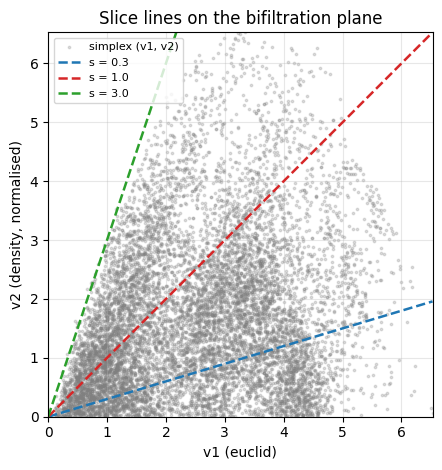

In [3]:
bp_demo = BifiltrationProcessor(f1_ir, f2_ir)
_f1_idx, _f2_idx = bp_demo._indexed_filtrations()
pts = np.array([(_f1_idx[s][0], _f2_idx[s][0])
                for s in _f1_idx if s in _f2_idx])

fig, ax = plt.subplots(figsize=(5.6, 4.8))
ax.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.25, color="grey",
           label="simplex (v1, v2)")
vmax = max(pts[:, 0].max(), pts[:, 1].max())
xs = np.linspace(0, vmax, 100)
for s, col in [(0.3, "C0"), (1.0, "C3"), (3.0, "C2")]:
    ax.plot(xs, s * xs, "--", color=col, lw=1.8, label=f"s = {s}")
ax.set_xlim(0, vmax); ax.set_ylim(0, vmax)
ax.set_xlabel("v1 (euclid)")
ax.set_ylabel("v2 (density, normalised)")
ax.set_title("Slice lines on the bifiltration plane")
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_aspect("equal", "box")
fig.tight_layout()
fig.savefig(FIG / "04_slice_geometry.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Clustering quality vs slope

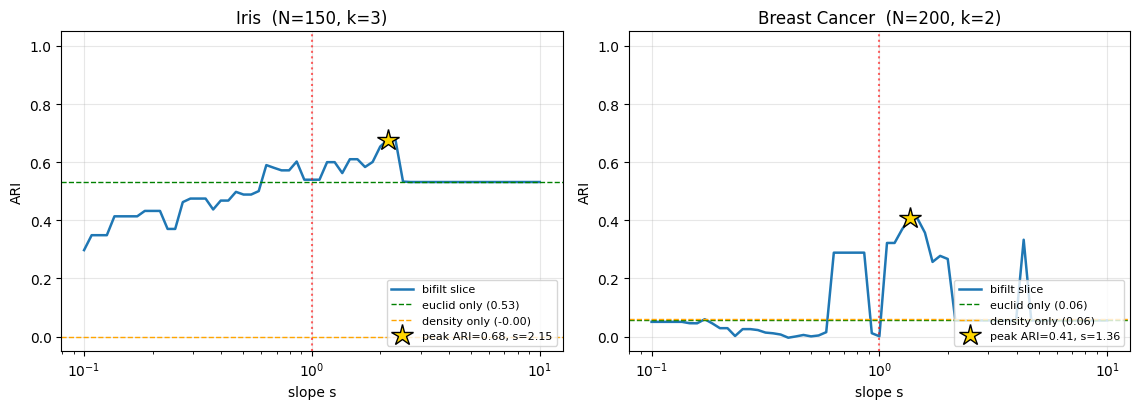

In [ ]:
slopes = np.geomspace(0.1, 10.0, 61)
datasets = [
    ("Iris", X_ir, y_ir, f1_ir, f2_ir, 3, "euclid", "density"),
    ("Breast Cancer", X_bc, y_bc, f1_bc, f2_bc, 2, "euclid", "density"),
]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for ax, (name, X, y, f1, f2, k, n1, n2) in zip(axes, datasets):
    curve = np.array([
        adjusted_rand_score(y, slice_labels(f1, f2, len(X), s, 0.0, k))
        for s in slopes
    ])
    b1 = adjusted_rand_score(y, single_labels(f1, len(X), k))
    b2 = adjusted_rand_score(y, single_labels(f2, len(X), k))
    ax.semilogx(slopes, curve, "-", color="C0", lw=1.8, label="bifilt slice")
    ax.axhline(b1, ls="--", color="green",  lw=1, label=f"{n1} only ({b1:.2f})")
    ax.axhline(b2, ls="--", color="orange", lw=1, label=f"{n2} only ({b2:.2f})")
    ax.axvline(1.0, ls=":", color="red", alpha=0.6)
    i = int(curve.argmax())
    ax.plot(slopes[i], curve[i], "*", color="gold",
            markersize=16, markeredgecolor="black", zorder=5,
            label=f"peak ARI={curve[i]:.2f}, s={slopes[i]:.2f}")
    ax.set_title(f"{name}  (N={len(X)}, k={k})")
    ax.set_xlabel("slope s")
    ax.set_ylabel("ARI")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(FIG / "04_quality_vs_slope.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Vineyard

Six dendrograms at different slopes, plus a vineyard plot showing the top-10 merge heights as a function of slope.                                                                                                  
   
Red curves are the two highest merges. A k=3 cut skips exactly these, so they define the boundaries between the three clusters.                                                                                   
Grey curves are the next 8 merges, which sit inside the resulting clusters.
                                                                                                                                                                                                                    
When two curves cross, the cluster assignment at that slope changes, a different merge becomes one of the top 2.

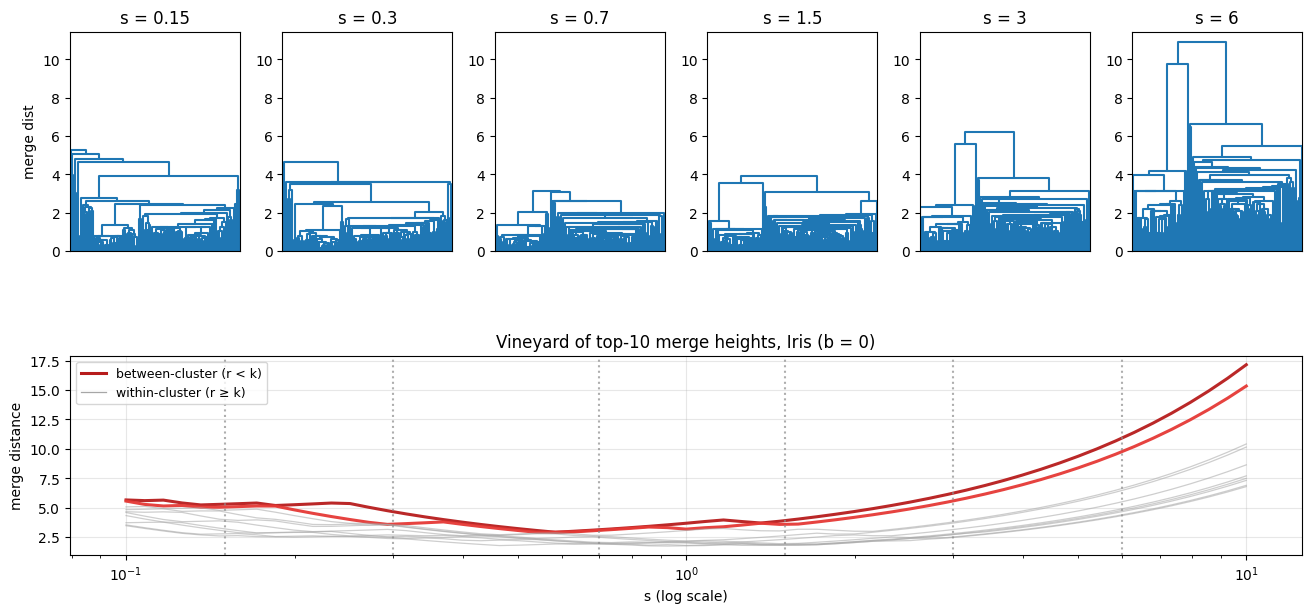

In [5]:
plot_vineyard(
    Z_func=lambda s: slice_Z(f1_ir, f2_ir, len(X_ir), s, 0.0),
    param_values=slopes,
    demo_values=[0.15, 0.3, 0.7, 1.5, 3.0, 6.0],
    param_name="s", log_x=True, k=3,
    title="Vineyard of top-10 merge heights, Iris (b = 0)",
    filename="04_vineyard_slope.png",
)

## 4. Vineyard at s = 1

Slope fixed at s = 1. The offset b sweeps from 0 to 0.25 * v2_max. Positive b lifts the slicing line off the origin, which delays simplices with small v2.
   
Dataset: Breast Cancer (k = 2, density over PCA-5 space)

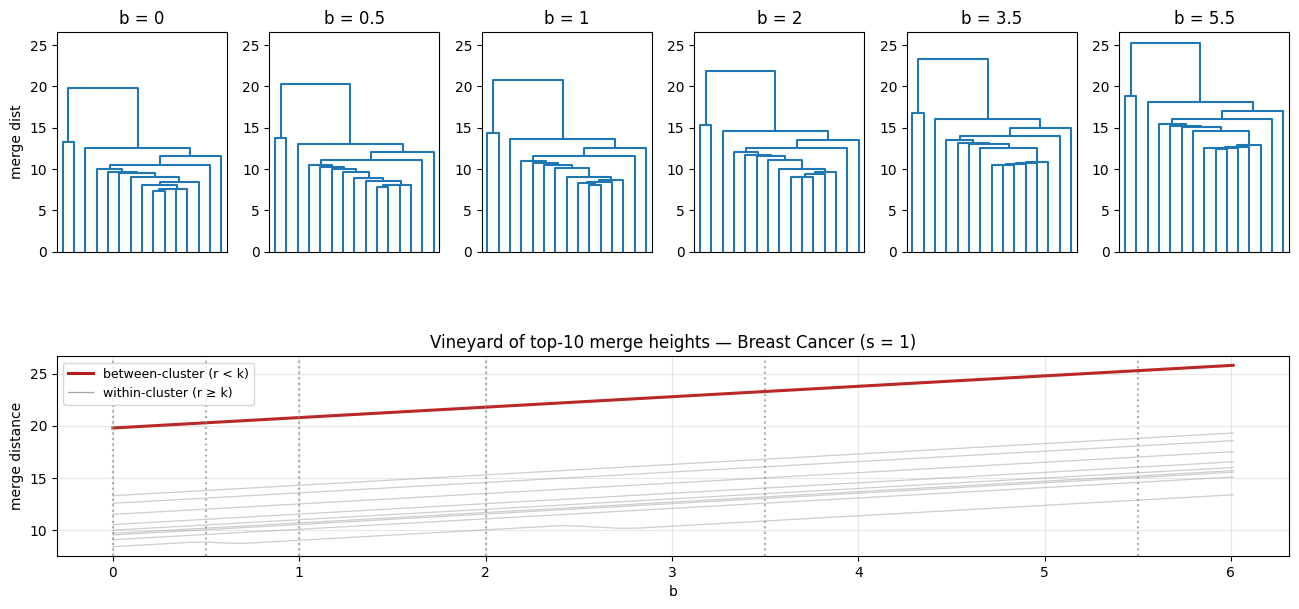

In [6]:
v2_max = max(v for _, v in f2_bc)
offsets = np.linspace(0.0, 0.25 * v2_max, 61)

plot_vineyard(
    Z_func=lambda b: slice_Z(f1_bc, f2_bc, len(X_bc), 1.0, b),
    param_values=offsets,
    demo_values=[0.0, 0.5, 1.0, 2.0, 3.5, 5.5],
    param_name="b", log_x=False, k=2,
    title="Vineyard of top-10 merge heights — Breast Cancer (s = 1)",
    filename="04_vineyard_offset.png",
    truncate=15,
)